In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
import cmath

/home/alonso/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
PI = np.pi

In [3]:
def fourier_coefficients(n_max):

    coef = gen.normal(0, 1, size = (n_max + 1, 2))
    coef = np.append(coef, np.flipud(coef[:-1,:]), 0)
    coef[n_max, 1] = 0
    coef[n_max + 1:, 1] *= -1
    coef = coef[:, 0] + 1j * coef[:,1]

    return coef

In [4]:
def slow_phi(x, y, L_x, L_y, eta, u_0, V_d, a_k, n_max, L_tot):

    n_rows, n_cols = X.shape
    flow = np.zeros([n_rows, n_cols], dtype=complex)
    L_tot = 2*L

    d = 2
    V_d = L_x * L_y
    K = np.arange(-n_max, n_max + 1) / L
    k = 2 * PI * n_max / L_tot
    num = eta**(d / 2 + 1) * u_0
    den = np.sqrt(V_d * d * (d - 1)) 

    for i in range(n_rows):
        for j in range(n_cols):

            base = np.exp((x[i, j] * K + y[i, j] * K) * 1j)

        
            fourier_sum = np.exp(-(k * eta / 2)**2) * np.sum(a_k * base)#* np.dot(a_k, base, dtype = complex)
            flow[i, j] = (2 * PI)**(d/4) * num / den * fourier_sum

    flow = np.real_if_close(flow)

    return flow

In [5]:
def phi(x, y, L_x, L_y, eta, u_0, V_d, a_k, n_max, L_tot):

    d = 2
    V_d = L_x * L_y
    K = np.arange(-n_max, n_max + 1)
    k = 2 * PI * n_max / L_tot
    base = np.exp((x * K + y * K) * complex(0, 1))

    num = eta**(d / 2 + 1) * u_0
    den = np.sqrt(V_d * d * (d - 1))  
    fourier_sum = np.exp(-(k * eta / 2)**2) * np.sum(a_k * base)

    flow = (2 * PI)**(d/4) * num / den * fourier_sum

    return flow

In [ ]:
def real_corr(x, x_prime, y, y_prime, eta, u_0, d):

    distance = (x - x_prime)**2 + (y - y_prime)**2
    
    corr = eta**2 * u_0**2 / (d * (d - 1)) * np.exp(-distance**2 / (2 * eta**2))

    return corr

In [34]:
def real_u_corr(x, x_prime, y, y_prime, eta, u_0, d):

    distance = (x - x_prime)**2 + (y - y_prime)**2

    corr = u_0**2 / (d * (d - 1)) * ((y - y_prime)**2 / eta**2 - 1) * np.exp(-distance**2 / (2 * eta**2))

    return corr

In [6]:
n_0 = 4.07
p_0 = 0.121
i_n = 0.9
a = 8
m_n = 0.03
f_p = 0.9
d = 0.04
nu_max = 0.3
r_0 = 10
n_eddies = 100
L = 100
A = 1
T = 1000
dt = 0.12
N = 180

dx = 2 * L / N

L_x, L_y, L_z = 2*L, 2*L, 0
u_0 = 0.3
eta = 1
n_max = 2*L
V_d = L_x * L_y

In [7]:
gen = np.random.default_rng(seed = 26)

In [8]:
a_k = fourier_coefficients(n_max)

In [9]:
x, y = np.arange(-L, L+1), np.arange(-L, L+1)
X, Y = np.meshgrid(x, y)

In [10]:
X.shape

(201, 201)

In [11]:
n_rows, n_cols = X.shape
flow = np.zeros([n_rows, n_cols], dtype=complex)
L_tot = 2*L

d = 2
V_d = L_x * L_y
K = np.arange(-n_max, n_max + 1) / L
k = 2 * PI * n_max / L_tot
num = eta**(d / 2 + 1) * u_0
den = np.sqrt(V_d * d * (d - 1)) 

for i in range(n_rows):
    for j in range(n_cols):

        base = np.exp((X[i, j] * K + Y[i, j] * K) * 1j)

        
        fourier_sum = np.exp(-(k * eta / 2)**2) * np.sum(a_k * base)#* np.dot(a_k, base, dtype = complex)
        flow[i, j] = (2 * PI)**(d/4) * num / den * fourier_sum

        #flow[i, j] = phi(X[i, j], Y[i, j], 2*L, 2*L, eta, u_0, V_d, a_k, n_max, 2*L)

flow = np.real_if_close(flow)

In [12]:
slo_flo = slow_phi(X, Y, L_x, L_y, eta, u_0, V_d, a_k, n_max, L)
#flo = phi(X, Y, L_x, L_y, eta, u_0, V_d, a_k, n_max, L)

In [15]:
phi_y, phi_x = np.gradient(slo_flo, dx)

In [ ]:
u = phi_y
v = -phi_x

In [32]:
distances = np.linspace(0, 100, 1000)
correlations = real_corr(distances, eta, u_0, d)

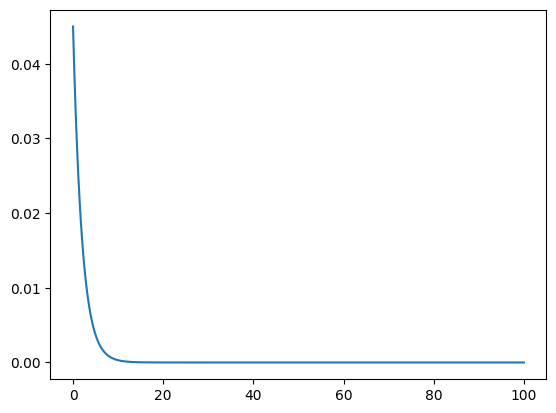

In [33]:
plt.plot(distances, correlations)
plt.show()

In [35]:
x = 0
x_prime =1
y = 1
y_prime = 0 

In [51]:
n_est = 10000
phis, phis_prime = np.array([]), np.array([])

for _ in range(n_est):

    a = fourier_coefficients(n_max)
    flo = slow_phi(X, Y, L_x, L_y, eta, u_0, V_d, a,n_max, L_tot)
    phi_normal = flo[x, y]
    phi_prime = flo[x_prime, y_prime]

    phis = np.append(phis, phi_normal)
    phis_prime = np.append(phis_prime, phi_prime)

KeyboardInterrupt: 

In [52]:
t = np.arange(1,len(phis)+1)
cum_means = np.cumsum(phis * phis_prime / t)

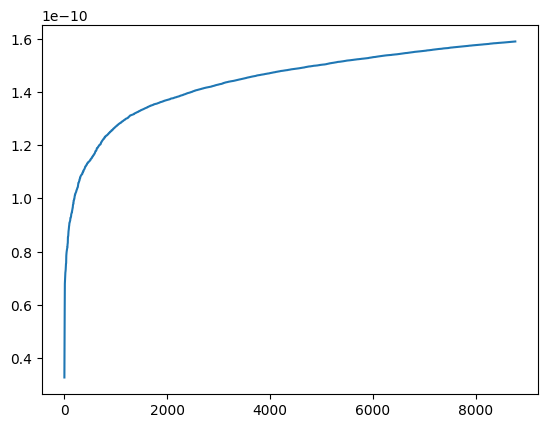

In [53]:
plt.plot(t, cum_means)
plt.show()